# Recession Prediction Using Yield Curve Factors

*By Vlad Popa*

The **yield curve** is a graphical representation that represents yields of (governmental) bonds at equal credit quality, but different maturities. It is a well known and reliable market signal with a history of preceding US recessions when the curve flattens or inverts. The shape of the curve is driven by the short-term fed funds rate, and market speculations about long-term interest rates. 

In this notebook, I use US bond yields across maturities to extract yield curve factors via PCA, and use those factors to estimate recession probability via several binary response models, at different time lag windows. 

Before diving into the code, please consult the read.me document for information regarding limitations, assumptions and more.

## 1. Import Libraries and Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import norm, t
from scipy.optimize import minimize

In [2]:
# Load formatted data
y = pd.read_csv(r"files\data\f_USREC.csv").set_index("date").values

yc_data = pd.read_csv(r"files\data\f_YC-rates-1990-2023.csv").set_index("date")
maturities = yc_data.columns.tolist()
X = yc_data.values

## 2. Principal Component Analysis 

**PCA (Principal Component Analysis)** is a dimensionality reduction technique that reduces the number of features in a dataset into a smaller set of uncorrelated components through the computation of eigenvectors and eigenvalues from the covariance matrix. The PCA is particularly useful in this project as yields at different maturities are highly correlated. Using PCA breaks them down into new uncorrelated variables with easier interpretation.

In [72]:
# Standardize the data 
scaler = StandardScaler() 
X_f = scaler.fit_transform(X) 

# Apply PCA 
pca = PCA(n_components=3) 
X_pca = pca.fit_transform(X_f) 

# Compute percentage of variance explained for each component 
eigvals = np.round(pca.explained_variance_ratio_ * 100, decimals=2) 

# Compute eigenvector loadings 
eigvecs = pca.components_

Based on the eigenvalues of the covariance matrix, it can be shown that the first 3 PCs explain more than 99% of the total yield curve variance. Thus for certain applications it might be sufficient to only work with these limited number of factors. 

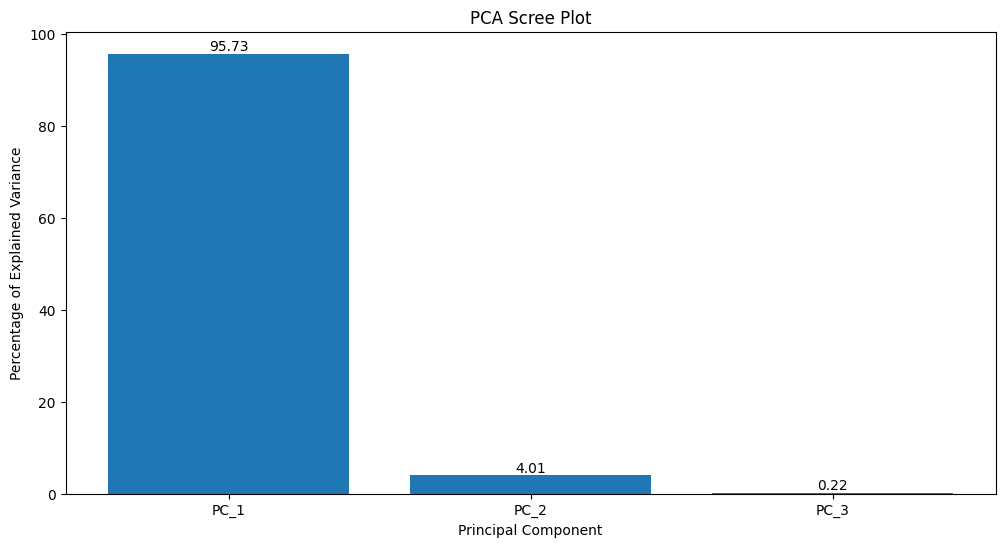

In [73]:
# Visualize percentage explained by eigenvalues
plt.figure(figsize=(12, 6))
labels = []
for i in range(1, len(eigvals) + 1):
    labels.append("PC_" + str(i))

bars = plt.bar(x=range(1, len(eigvals) + 1), height=eigvals, tick_label=labels)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principal Component")
plt.title("PCA Scree Plot")
plt.show()

Through the derivation of the covariance matrix' eigenvalues, the identified PCs can be interpreted as the "level", "slope", "curvature" of the yield curve.


The eigenvector loadings show how each maturity contributes to a PC in terms of movement patterns. Based on the figure, we can interpret the PCs as follows:
- PC_1: All loadings are roughly equal and same sign. This is the **level** factor, and it explains roughly 95.73% of the yield curve variance.
- PC_2: Short-term rates are low while long-term rates are up. This is the **slope** factor under normal circumstances, and explains around 4.01% of the yield curve variance.
- PC_3: Middle maturities move differently than short and long ones. This is the **curve** factor, and it explains approximately 0.22% of the yield curve variance.

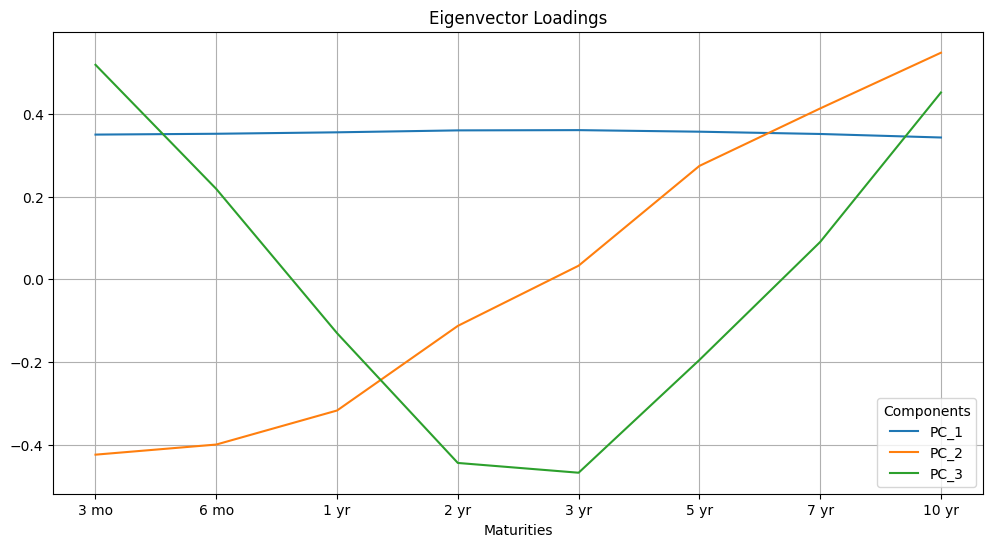

In [74]:
# Visualize eigenvector loadings
plt.figure(figsize=(12, 6))
for j in range(len(eigvecs)):
    plt.plot(eigvecs[j], label=labels[j])

plt.xticks(range(len(eigvecs[0])), maturities)
plt.legend(title="Components")
plt.xlabel("Maturities")
plt.title("Eigenvector Loadings")
plt.grid()
plt.show()

## 3. Feature Specification
Define features of the slope spread and the PCA 

In [128]:
# Define a benchmark model params based on the 10Y - 2Y slope spread
slope_spread = yc_data["10 yr"].values - yc_data["2 yr"].values
X_spread = np.column_stack((np.ones(len(slope_spread)), slope_spread))
k_spread = X_spread.shape[1]
par_spread = np.append(np.zeros(k_spread), 1)

# Define the PCA model params
oX_pca = np.column_stack((np.ones(len(X_pca)), X_pca))
k_pca = oX_pca.shape[1]
par_pca = np.append(np.zeros(k_pca), 1)

## 4. Binary Response Models
Estimating the Binary Logit, Probit, Gompit, Log-log and Gosset model using maximum likelihood.

In [141]:
# Template function for computing loglikelihood of a model
def template_logL(par, X, model):
  b = par[:-1]
  z = X @ b

  # For Gosset, estimate coefficients and nu
  if model == gosset_cdf:
    v = par[-1]
    if v <= 0:
      return np.inf
    Pr_y_1_x = model(z, v)

  # All other models, estimate coefficients
  else:
    Pr_y_1_x = model(z)

  Pr_y_1_x = np.clip(Pr_y_1_x, 1e-10, 1-1e-10)
  loglikelihood = np.sum(y * np.log(Pr_y_1_x) + (1-y) * np.log(1-Pr_y_1_x))
  return -loglikelihood

# CDF of the Logit model
def logit_cdf(z):
  Pr_y_1_x = 1 / (1 + np.exp(-(z)))
  return Pr_y_1_x

# CDF of the Probit model
def probit_cdf(z):
  Pr_y_1_x = norm.cdf(z)
  return Pr_y_1_x

# CDF of the Gompit model
def gompit_cdf(z):
  Pr_y_1_x = 1 - np.exp(- np.exp(z))
  return Pr_y_1_x

# CDF of the Log-log model
def loglog_cdf(z):
  Pr_y_1_x = np.exp(- np.exp(- (z)))
  return Pr_y_1_x

# CDF of the Gosset model
def gosset_cdf(z, nu):
    return t.cdf(z, df=nu)

In [142]:
# Dictionary of feature sets
feat_sets = {"Benchmark Model": (par_spread, X_spread),
          "PCA Model": (par_pca, oX_pca)}

# Dictionary of binary response models
bin_models = {"Logit":logit_cdf,
          "Probit":probit_cdf,
          "Gompit":gompit_cdf,
          "Log-log":loglog_cdf,
          "Gosset":gosset_cdf}

# Dictionary containing the estimated parameters for each set of features
feat_est_par = {}

# Cycle through the PCA and slope parameters
for feat_name, (feat_par, feat_X) in feat_sets.items():
    print("-------------------------------------------")
    print(f"Using {feat_name} features...")
 
    # Cycle through the estimated beta's, nu and likelihood for each binary model
    for bin_name, bin_cdf in bin_models.items():
        model_est_par = {}
        res = minimize(template_logL, feat_par, args=(feat_X, bin_cdf,), method="L-BFGS-B")
        model_cofs = res.x
        print(f"Estimated {bin_name}")
        if bin_name == "Gosset":
            print(f"- nu = {model_cofs[-1]}")
        for idx, coef in enumerate(model_cofs[:-1]):
            print(f"- beta{idx} = {coef}")
        model_est_par[bin_name] = model_cofs
        max_logL = -res.fun
        print(f"- Maximized logL = {max_logL}\n")
    feat_est_par[feat_name] = model_est_par

-------------------------------------------
Using Benchmark Model features...
Estimated Logit
- beta0 = -2.343094586113427
- beta1 = -2.850899680621494e-06
- Maximized logL = -21472492.838856716

Estimated Probit
- beta0 = -1.355582521282626
- beta1 = -3.008903284504915e-08
- Maximized logL = -21472492.838832494

Estimated Gompit
- beta0 = -2.38928958855306
- beta1 = -2.6065480811364915e-06
- Maximized logL = -21472492.8388459

Estimated Log-log
- beta0 = -0.8898599883573087
- beta1 = -4.2871927985647903e-07
- Maximized logL = -21472492.838829357

Estimated Gosset
- nu = 1.3361471174518775
- beta0 = -2.6612353188488584
- beta1 = -8.901296257447609e-07
- Maximized logL = -21472492.838828247

-------------------------------------------
Using PCA Model features...
Estimated Logit
- beta0 = -2.3430936820708466
- beta1 = 3.6388111770102324e-07
- beta2 = -9.843774313393379e-06
- beta3 = -3.437814627049799e-06
- Maximized logL = -21472492.838930078

Estimated Probit
- beta0 = -1.3555821194619